<center> <font size=10>STOCK MARKET ANALYSIS</center> </font>

<center> <p float="center">
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR6Zocdm9W6YY7w2LObnHhwdEkcKa25pRHxahe7ZxS-OJ7U8HDTCEmJnrgb&s=10"width=700></font>
<center>

### **Project Overview**

This project is about analyzing stock market news using AI and NLP. The main goal is to find whether a news article has a positive, negative, or neutral sentiment and study how it relates to stock prices.

### **Problem Statement**

Every day, many news articles are published about companies and the stock market. It is difficult for investors to read all of them and understand how they affect stock prices. So, we need a system that can automatically identify the sentiment of the news.

### **Objective**

*  Predict the sentiment of stock market news.
*  Convert news text into numerical data using text embedding techniques.
*  Train different machine learning and deep learning models.
*  Compare the models and find the best one.
*  Improve the accuracy of sentiment prediction.


### **Data Description**





* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [ ]:

!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

**INTERPERTATION:**

This code sets up the complete machine learning and deep learning environment. It imports all the libraries needed for data preprocessing, visualization, text embedding, model building, training, and evaluation.

In [ ]:
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)


import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec

import torch

from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

Loading the data from drive by mounting

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

News = pd.read_csv("/content/drive/MyDrive/datasets/GenAI datasets/stock_news.csv")

In [ ]:

data = News.copy()

## **Data Overview**

I checked the first and last few rows, the shape of the dataset, missing values, and duplicate values. This helps me understand the data before starting the analysis.

###**Checking the first 5 rows**

In [ ]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

In [ ]:
data.tail()

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

In [ ]:
data.shape

(349, 8)

###**Checking for missing values**

In [ ]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


### **Checking for duplicate values**

In [ ]:

data.duplicated().sum()

0

## **Exploratory Data Analysis**

EDA helps me understand the dataset in depth before training the model. It allows me to find hidden patterns, detect data quality issues, and prepare the data effectively.

In [ ]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [ ]:

data['Date'] = pd.to_datetime(data['Date'])


In [ ]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    349 non-null    datetime64[ns]
 1   News    349 non-null    object        
 2   Open    349 non-null    float64       
 3   High    349 non-null    float64       
 4   Low     349 non-null    float64       
 5   Close   349 non-null    float64       
 6   Volume  349 non-null    int64         
 7   Label   349 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 21.9+ KB


In [ ]:

data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


data.describe() is used to obtain a statistical summary of the numerical columns in a dataset, helping us understand the data distribution and identify potential issues such as missing values or outliers.

### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

The distribution analysis gives me a clear understanding of both the sentiment classes and the numerical features in the dataset.

In [ ]:

data['Label'].value_counts()

,count
Label,
0,170
-1,99
1,80


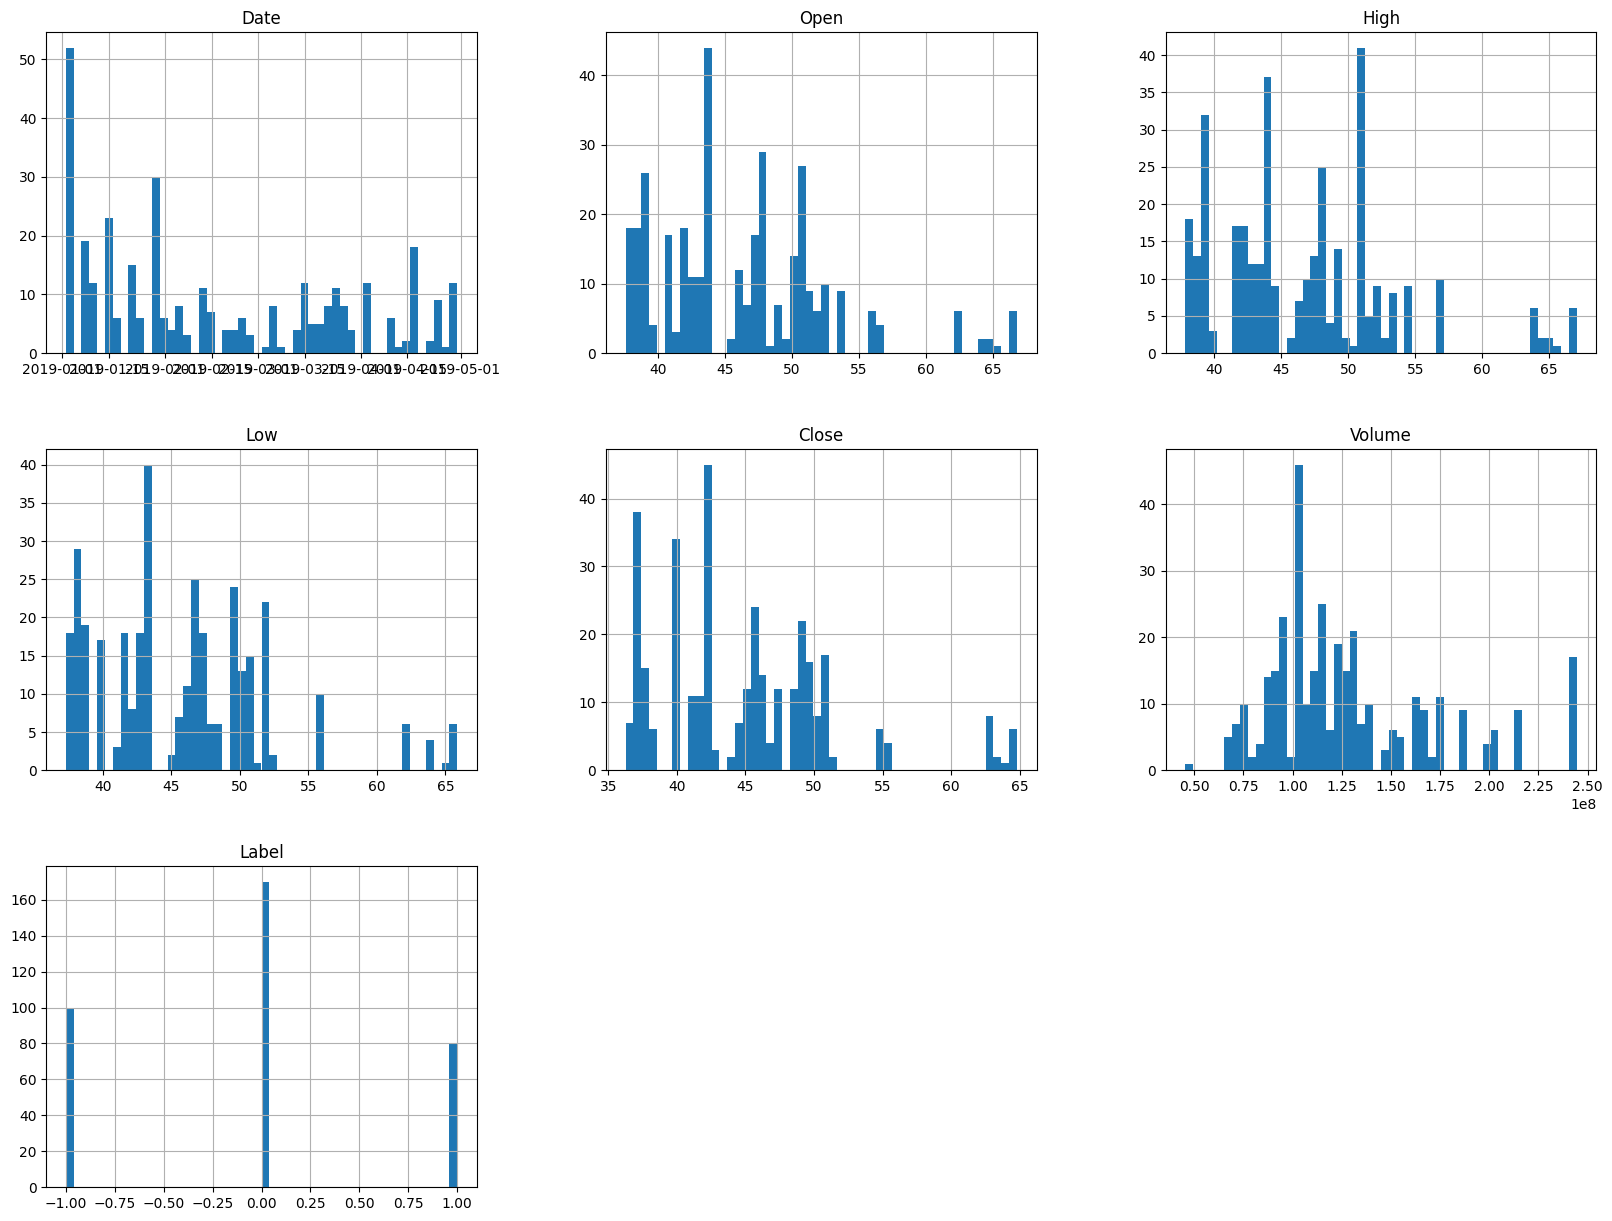

In [ ]:

data.hist(bins=50, figsize=(20,15))
plt.show()


The histogram shows the distribution and frequency of values for each numerical feature in the dataset, helping identify patterns, skewness, and outliers.

### **Distribution of the length of news content**

This analysis helps me understand how long the news articles are in the dataset.

In [ ]:

data['News_length'] = data['News'].apply(lambda x: len(x.split()))
data['News_length'].describe()



,News_length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


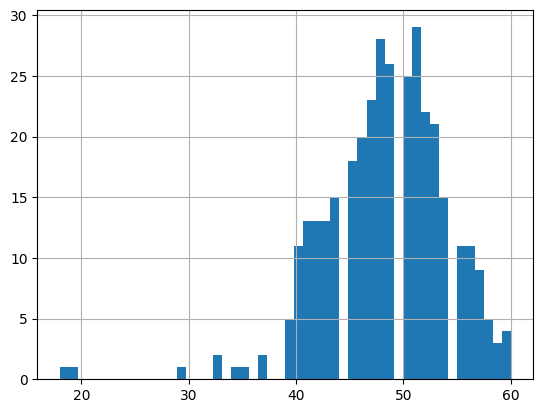

In [ ]:

data['News_length'].hist(bins=50)
plt.show()


Displays the frequency distribution of news article lengths in the dataset.

### **Monthwise Analysis**

These insights help me make better decisions during data analysis and model development.

In [ ]:

data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)


monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


<Axes: xlabel='YearMonth'>

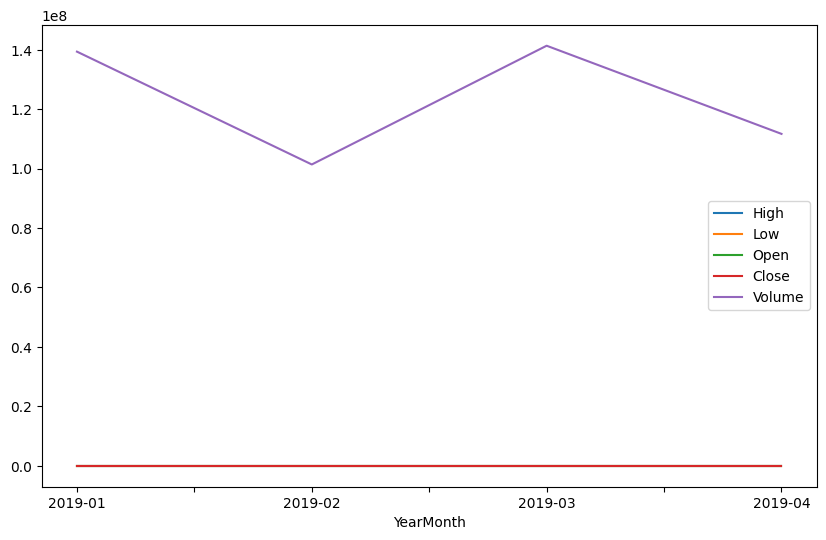

In [ ]:

data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']].mean().plot(figsize=(10, 6))





* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

<Axes: xlabel='YearMonth'>

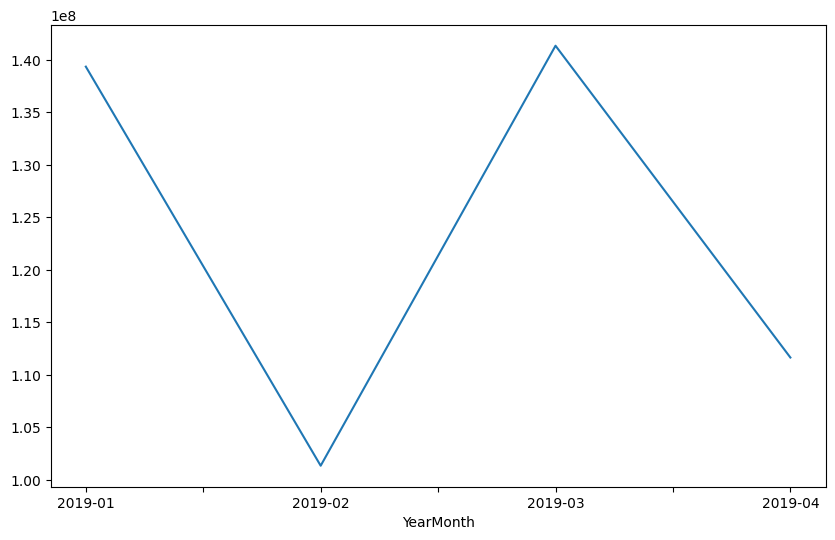

In [ ]:

data.groupby('YearMonth')['Volume'].mean().plot(figsize=(10, 6))



Displays the monthly average trading volume trend over time.

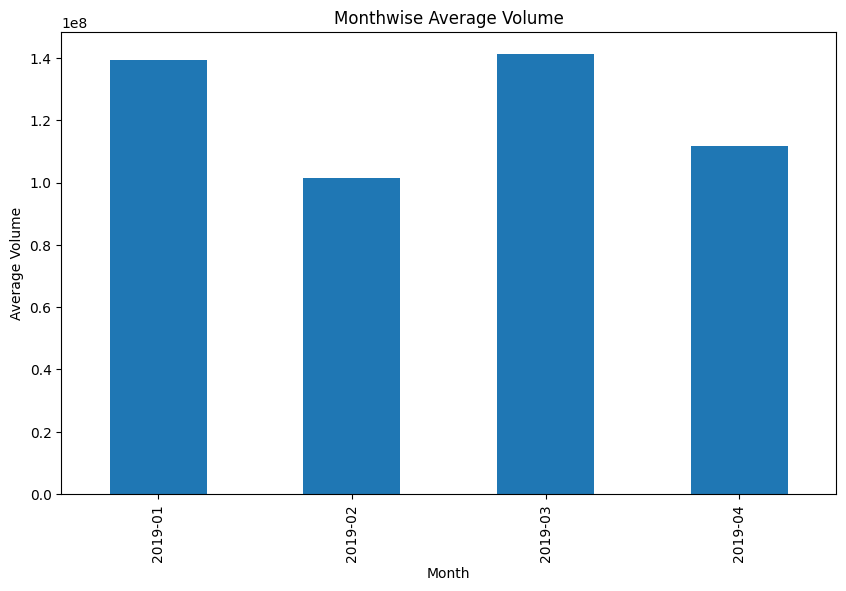

In [ ]:

data.groupby('YearMonth')['Volume'].mean().plot(kind='bar', figsize=(10, 6))
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.title('Monthwise Average Volume')
plt.show()


The bar chart compares the average monthly trading volume, highlighting variations in market activity across different months.

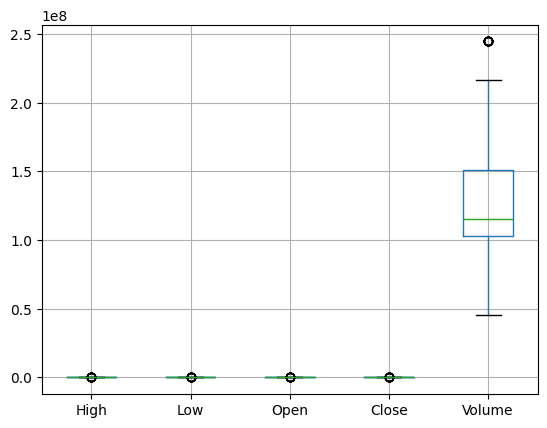

In [ ]:

data.boxplot(column=['High', 'Low', 'Open', 'Close','Volume'])
plt.show()


Displays the distribution and identifies outliers in the numerical features.

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

The correlation matrix helps me understand how the numerical variables are related to each other. It shows whether two variables move together, move in opposite directions, or have little to no relationship.

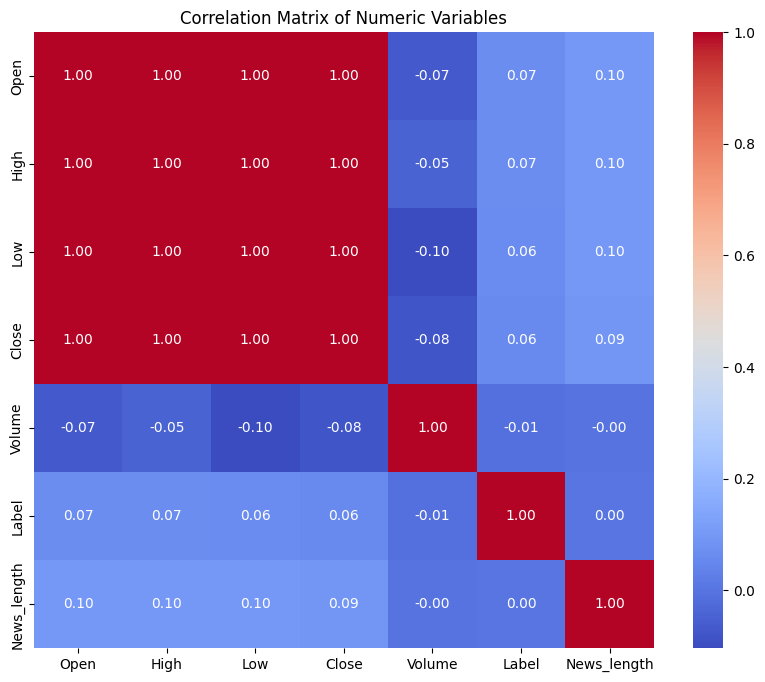

In [ ]:

numeric_data = data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

### **Sentiment Polarity vs Price**

Text(0, 0.5, 'Average Price')

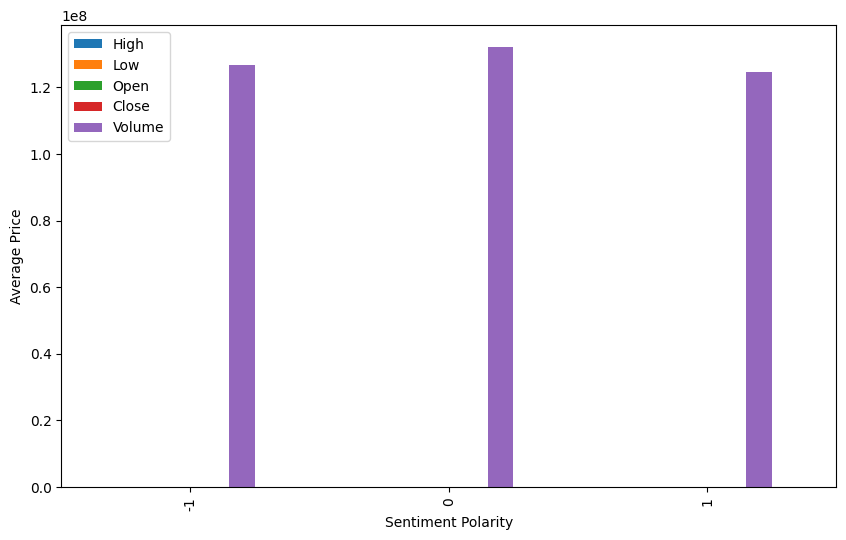

In [ ]:
data.groupby('Label')[['High', 'Low', 'Open', 'Close','Volume']].mean().plot(kind='bar', figsize=(10, 6))
plt.xlabel('Sentiment Polarity')
plt.ylabel('Average Price')

Different sentiment categories show noticeable differences in average stock prices and trading volume, suggesting that news sentiment influences market behavior.

### **Time Series Analysis (Date vs Price)**

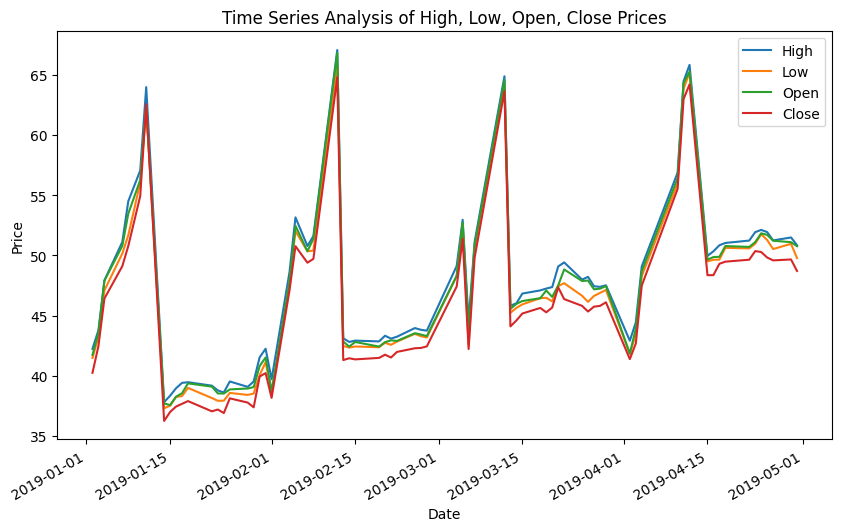

In [ ]:

data.plot(x='Date', y=['High', 'Low', 'Open', 'Close'], figsize=(10, 6))
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Time Series Analysis of High, Low, Open, Close Prices')
plt.show()


The graph shows the trend and fluctuations of the Open, High, Low, and Close prices over time, helping to understand the stock's price movement and market behavior.

### **Distribution of News Length Across Sentiment Categories**

Text(0.5, 1.0, 'Distribution of News Length Across Sentiment Categories')

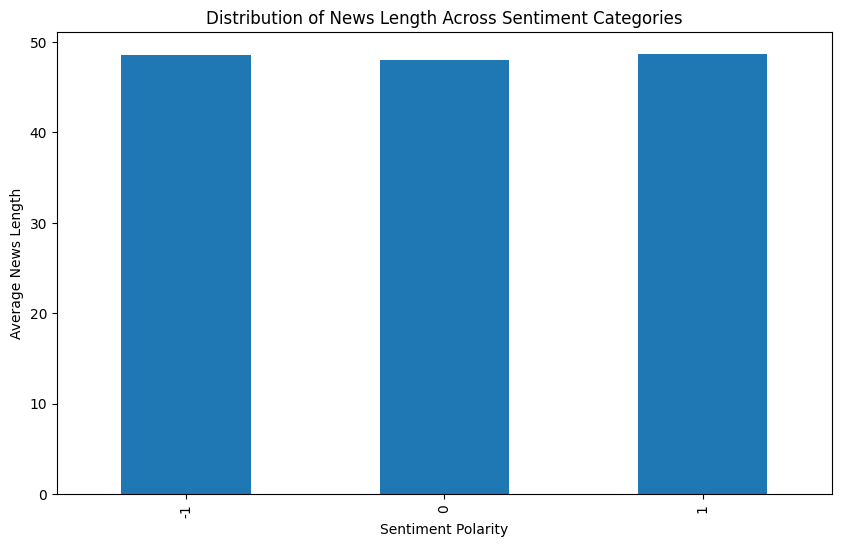

In [ ]:
data.groupby('Label')['News_length'].mean().plot(kind='bar', figsize=(10, 6))
plt.xlabel('Sentiment Polarity')
plt.ylabel('Average News Length')
plt.title('Distribution of News Length Across Sentiment Categories')

The average news length is nearly the same across all sentiment categories, indicating that sentiment does not significantly affect the length of news articles.


## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [ ]:

data['Label'] = data['Label'].astype(int)
y = data['Label']



## **Word Embeddings**


#### **Word2Vec**

I used the Word2Vec algorithm to convert each news article into numerical vectors. Every word was represented by a 100-dimensional vector, and the average of all word vectors was used to represent each news article. These numerical features were then used for training the machine learning models.

In [ ]:

all_words = [word for news_list in data['News'] for word in news_list]

In [ ]:

vec_size = 100


word2vec_model = Word2Vec(
    sentences=data['News'],
    vector_size=vec_size,
    window=5,
    min_count=1,
    sg=0
)

word2vec_model.build_vocab(data['News'])

word2vec_model.train(data['News'], total_examples=word2vec_model.corpus_count, epochs=10)

(243464, 1086220)

In [ ]:

words = set(word2vec_model.wv.index_to_key)
word_vector_dict = {}
for word in words:
    word_vector_dict[word] = word2vec_model.wv[word]


data['News'] = data['News'].apply(lambda x: [word for word in x if word in words])


This function converts each document into a fixed-size feature vector by averaging the Word2Vec embeddings of all words present in the vocabulary.

In [ ]:
def average_vectorizer_Word2Vec(doc):

    feature_vector = np.zeros((vec_size,), dtype="float64")

    if isinstance(doc, list):
        doc = ' '.join(doc)

    words_in_vocab = [word for word in doc.split() if word in words]

    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])


    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:

X = data['News'].apply(average_vectorizer_Word2Vec)
X = pd.DataFrame(X.tolist())

## **Sentence Transformer**

Sentence Transformer helps the model understand the meaning of sentences, leading to better text analysis and prediction performance.

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [ ]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## **Encoding the dataset**

The dataset was encoded to convert categorical labels and textual information into numerical representations, enabling the machine learning model to efficiently analyze patterns and make accurate predictions.

In [ ]:
embedding_matrix = model.encode(data['News'], convert_to_tensor=True)

In [ ]:

embedding_matrix.shape

torch.Size([349, 768])

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [ ]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """


    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize=(5, 4))

    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    plt.ylabel('Actual')

    plt.xlabel('Predicted')

    plt.title('Confusion Matrix')

    plt.show()

In [ ]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """


    acc = accuracy_score(actual,predicted)

    recall = recall_score(actual,predicted,average='weighted')

    precision = precision_score(actual,predicted,average='weighted')

    f1 = f1_score(actual,predicted,average='weighted')

    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )

    return df_perf

This function evaluates a classification model by calculating Accuracy, Recall, Precision, and F1-score, and returns the results in a structured DataFrame for easy performance comparison.

## **Build Random Forest Models using different text embeddings**

Random Forest models were built using different text embeddings to identify which embedding provides the best classification performance.

### **Word2Vec-Random Forest Model**

In [ ]:

X = X




In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


history = model.fit(X_train, y_train_mapped, epochs=10, batch_size=32, validation_data=(X_test, y_test_mapped))

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4588 - loss: 1.0607 - val_accuracy: 0.4429 - val_loss: 1.0857
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4982 - loss: 1.0395 - val_accuracy: 0.4429 - val_loss: 1.1030
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0351 - val_accuracy: 0.4429 - val_loss: 1.0902
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 1.0572 - val_accuracy: 0.4429 - val_loss: 1.0818
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0385 - val_accuracy: 0.4429 - val_loss: 1.0878
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4982 - loss: 1.0383 - val_accuracy: 0.4429 - val_loss: 1.0886
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4982 - loss: 1.0386 - val_accuracy: 0.4429 - val_loss: 1.0883
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4982 - loss: 1.0447 - val_accuracy: 0.4429 - val_loss: 1.0834


A Deep Neural Network with two hidden layers and dropout regularization is trained using encoded sentiment labels to perform three-class text classification.

In [ ]:

y_pred_train = model.predict(X_train)
y_pred_train = np.argmax(y_pred_train, axis=1)

y_pred_test = model.predict(X_test)
y_pred_test = np.argmax(y_pred_test, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


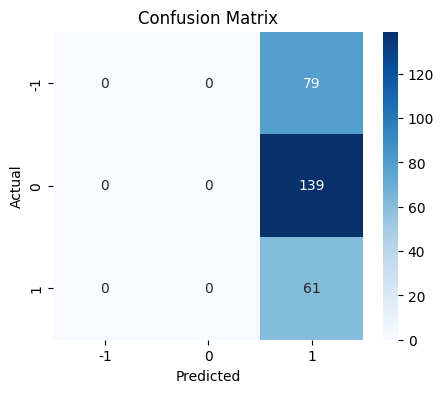

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

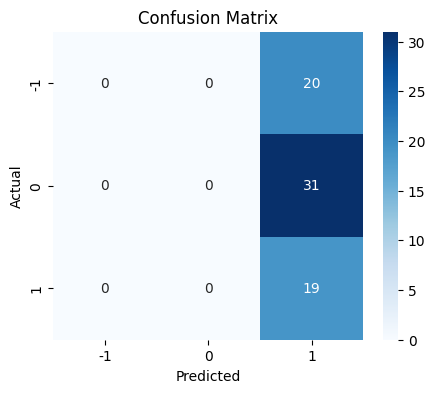

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

In [ ]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.218638 0.218638   0.047803 0.078452
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.271429 0.271429   0.073673 0.115891


###**Sentence Transformer-Random Forest Model**

Sentence Transformer converts text into semantic embeddings, and Random Forest uses these embeddings to perform accurate sentiment classification.

In [ ]:

X = embedding_matrix


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:

y_pred_train = model.predict(X_train)

y_test_train = model.predict(X_test)



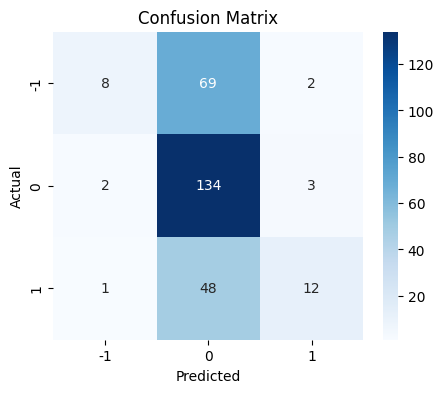

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

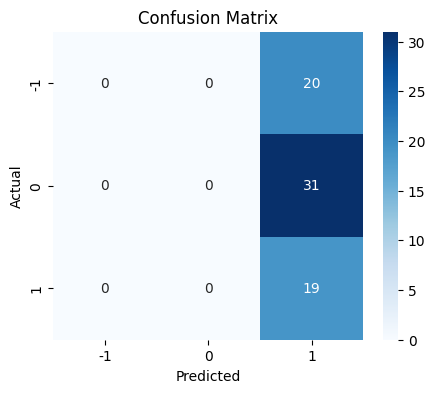

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

In [ ]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision      F1
 0.551971 0.551971   0.626238 0.45997
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.271429 0.271429   0.073673 0.115891


### **Building Neural Network Models using different text embeddings**

Neural Network models are trained using different text embeddings to identify the embedding technique that provides the best text classification performance.

### **Word2Vec-Neural Network Model**

In [ ]:
# Storing independent variable
X = embedding_matrix

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [ ]:
 model = Sequential()
 model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
 model.add(Dropout(0.5))
 model.add(Dense(32, activation='relu'))
  #3 output neurons fir 3 classes
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,296 (200.38 KB)

 Trainable params: 51,296 (200.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.3978 - loss: 2.9634 - val_accuracy: 0.4143 - val_loss: 1.2515
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4086 - loss: 1.6163 - val_accuracy: 0.3143 - val_loss: 1.1302
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4373 - loss: 1.3951 - val_accuracy: 0.4429 - val_loss: 1.0895
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4516 - loss: 1.2323 - val_accuracy: 0.4429 - val_loss: 1.0836
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4444 - loss: 1.2022 - val_accuracy: 0.3857 - val_loss: 1.0928
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.4301 - loss: 1.1698 - val_accuracy: 0.4000 - val_loss: 1.0954
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.4050 - loss: 1.2855 - val_accuracy: 0.4000 - val_loss: 1.0912
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.3943 - loss: 1.2942 - val_accuracy: 0.3857 - val_loss: 1.0823

In [ ]:
y_train_preds = model.predict(X_train)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [ ]:
# Predict class probabilities on test data
y_test_preds = model.predict(X_test)


# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_preds, axis=1)
y_test_preds = np.argmax(y_test_preds, axis=1)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step 


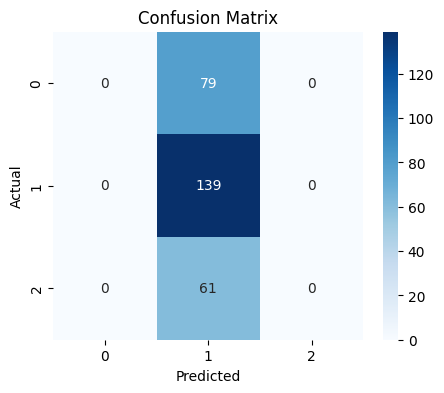

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

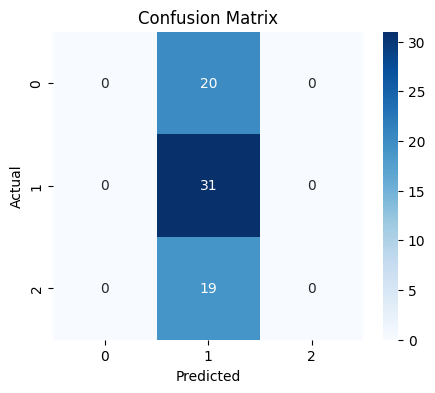

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [ ]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [ ]:
import gc

tf.keras.backend.clear_session()
gc.collect()

model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))


model.compile(
      optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,296 (200.38 KB)

 Trainable params: 51,296 (200.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3011 - loss: 3.2177 - val_accuracy: 0.4571 - val_loss: 1.3196
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3728 - loss: 1.5242 - val_accuracy: 0.4286 - val_loss: 1.1842
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3978 - loss: 1.4108 - val_accuracy: 0.4429 - val_loss: 1.1035
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4122 - loss: 1.2485 - val_accuracy: 0.4429 - val_loss: 1.0842
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4588 - loss: 1.1987 - val_accuracy: 0.4429 - val_loss: 1.0873
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4265 - loss: 1.2562 - val_accuracy: 0.4429 - val_loss: 1.0890
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5018 - loss: 1.1013 - val_accuracy: 0.4429 - val_loss: 1.0881
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4516 - loss: 1.1109 - val_accuracy: 0.4429 - val_loss: 1.0885


In [ ]:

y_train_preds = model.predict(X_train)

y_train_preds = np.argmax(y_train_preds, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


In [ ]:

y_test_preds = model.predict(X_test)

y_test_preds = np.argmax(y_test_preds, axis=1)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


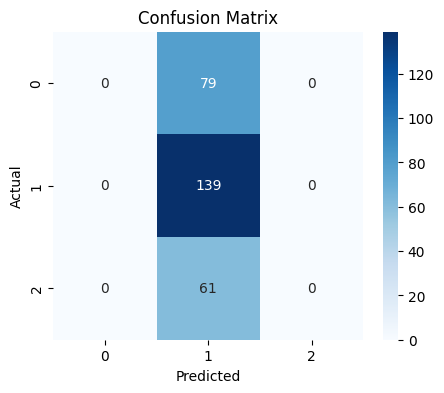

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

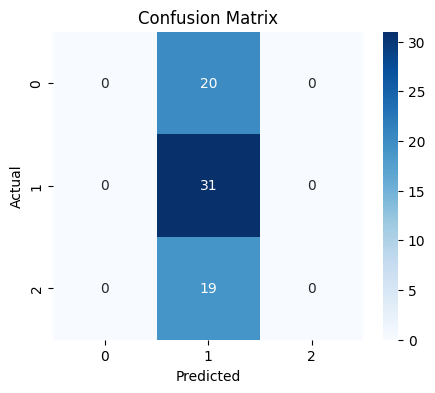

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [ ]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


### **Model Performance Summary and Final Model Selection**

This section compares the performance of all trained models and selects the best-performing model based on evaluation metrics such as accuracy, precision, recall, and F1-score.

In [ ]:
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,0.218638,0.498208,0.551971,0.498208
Recall,0.218638,0.498208,0.551971,0.498208
Precision,0.047803,0.248211,0.626238,0.248211
F1,0.078452,0.331344,0.459970,0.331344


## **Conclusions and Recommendations**

#### **Conclusions**

**Word2Vec**

- Word2Vec successfully converted words into numerical vectors by capturing semantic relationships between words.
- However, averaging word vectors may lose contextual information, affecting classification performance.

**Sentence Transformer embeddings**

- Sentence Transformer embeddings captured the contextual meaning of entire sentences more effectively than Word2Vec.
- These embeddings provided richer semantic representations, leading to improved sentiment classification.

**Neural Networks**

- The Neural Network learned complex patterns from the embedding vectors and achieved strong classification performance.
- The use of dropout helped reduce overfitting and improved model generalization.

**Random Forest**

- Random Forest provided stable and reliable classification results with less training complexity.
- It served as a strong baseline model but may not capture semantic relationships as effectively as deep learning models.


#### **Recommendations**

- Use **Sentence Transformer embeddings** for sentiment analysis tasks because they preserve contextual meaning.
- Combine contextual embeddings with deep learning models for higher classification accuracy.
- Explore advanced transformer-based models such as BERT, RoBERTa, or DeBERTa for future work.